# sky130 · SPICE → GDS (ALIGN) → KLayout

5 circuits on the open **sky130** PDK. **Run All** (~3–4 min); one-time `bash setup_align.sh`, project `.venv` kernel.

### Setup

In [1]:
import os, sys
os.environ.setdefault("QT_QPA_PLATFORM","offscreen")
from spice2gds import spice2gds, show_gds, available_pdks
print("PDKs:", available_pdks())

PDKs: ['Bulk45nm_Mock_PDK', 'Bulk65nm_Mock_PDK', 'FinFET14nm_Mock_PDK', 'GF180_PDK', 'Nonuniform_mock_pdk', 'SKY130_PDK']


## 1 · Inverter — `inverter`

DRC (ALIGN built-in check): ✓ clean — 0 errors
KLayout render: /home/irman/Gelochip/notebooks/align/runs/inverter/build/INVERTER_0.klayout.png


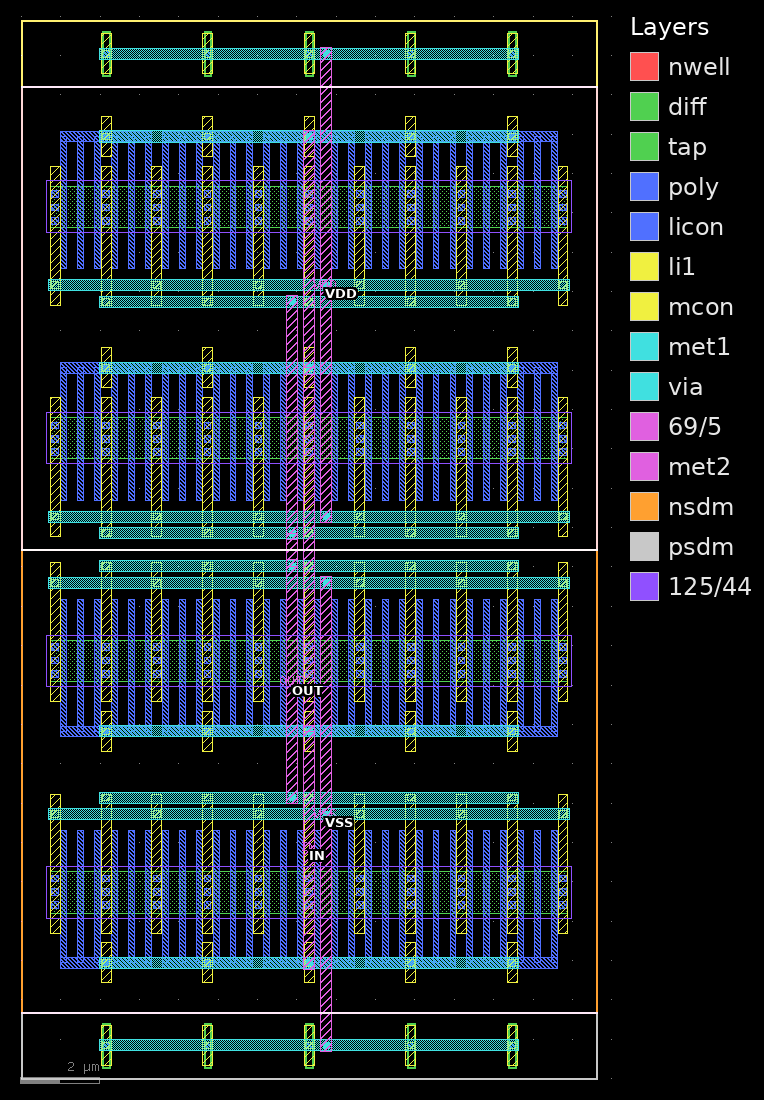

In [2]:
NETLIST = r"""
.subckt inverter vss vdd in out
mn0 out in vss vss nmos_lvt w=10.5e-7 L=150e-9 nf=20 stack=3
mp0 out in vdd vdd pmos_lvt w=10.5e-7 L=150e-9 nf=20 stack=3
.ends inverter
"""

gds = spice2gds("inverter", NETLIST, pdk="SKY130_PDK")
show_gds(gds)

## 2 · Buffer — `buffer`

In [ ]:
NETLIST = r"""
.subckt buffer vss vdd in out
mn0 out1 in vss vss nmos_rvt w=10.5e-7 l=150e-9 nf=10 m=1
mn1 out out1 vss vss nmos_rvt w=10.5e-7 l=150e-9 nf=10 m=1
mp0 out1 in vdd vdd pmos_rvt w=21e-7 l=150e-9 nf=10 m=1
mp1 out out1 vdd vdd pmos_rvt w=21e-7 l=150e-9 nf=10 m=1
.ends buffer
"""

gds = spice2gds("buffer", NETLIST, pdk="SKY130_PDK")
show_gds(gds)

## 3 · Current-mirror OTA — `current_mirror_ota`

In [ ]:
NETLIST = r"""
.subckt current_mirror_ota vss vdd vout vinn vinp id
M5 id id vss vss sky130_fd_pr__nfet_01v8 L=150e-09 stack=2 w=10.5e-7 nf=4
M4 source id vss vss sky130_fd_pr__nfet_01v8 L=150e-09 stack=2 w=10.5e-7 nf=4
M3 net7 vinn source vss sky130_fd_pr__nfet_01v8 L=150e-09 stack=2 w=10.5e-7 nf=8
M0 net8 vinp source vss sky130_fd_pr__nfet_01v8 L=150e-09 stack=2 w=10.5e-7 nf=8
M2 net7 net7 vdd vdd sky130_fd_pr__pfet_01v8 L=150e-09 stack=2 w=10.5e-7 nf=6
M6 vout net7 vdd vdd sky130_fd_pr__pfet_01v8 L=150e-09 stack=2 w=10.5e-7 nf=12
M1 net8 net8 vdd vdd sky130_fd_pr__pfet_01v8 L=150e-09 stack=2 w=10.5e-7 nf=6
M7 net9 net8 vdd vdd sky130_fd_pr__pfet_01v8 L=150e-09 stack=2 w=10.5e-7 nf=12
M8 net9 net9 source vss sky130_fd_pr__nfet_01v8 L=150e-09 stack=2 w=10.5e-7 nf=16
M9 vout net9 source vss sky130_fd_pr__nfet_01v8 L=150e-09 stack=2 w=10.5e-7 nf=16
.ends current_mirror_ota
"""

gds = spice2gds("current_mirror_ota", NETLIST, pdk="SKY130_PDK")
show_gds(gds)

## 4 · Five-transistor OTA — `five_transistor_ota`

In [ ]:
NETLIST = r"""
.subckt five_transistor_ota vss vdd vout vinn vinp id
M5 id id vss vss sky130_fd_pr__nfet_01v8 L=150e-9 w=10.5e-7 nf=10 stack=3
M4 source id vss vss sky130_fd_pr__nfet_01v8 L=150e-9 w=10.5e-7 nf=10 stack=3
M3 vout vinn source vss sky130_fd_pr__nfet_01v8 L=150e-9 w=10.5e-7 nf=20 stack=3
M0 net8 vinp source vss sky130_fd_pr__nfet_01v8 L=150e-9 w=10.5e-7 nf=20 stack=3
M2 vout net8 vdd vdd sky130_fd_pr__pfet_01v8 L=150e-9 w=10.5e-7 nf=20 stack=3
M1 net8 net8 vdd vdd sky130_fd_pr__pfet_01v8 L=150e-9 w=10.5e-7 nf=20 stack=3
.ends five_transistor_ota
"""

gds = spice2gds("five_transistor_ota", NETLIST, pdk="SKY130_PDK")
show_gds(gds)

## 5 · Telescopic OTA — `telescopic_ota`

In [ ]:
NETLIST = r"""
.subckt telescopic_ota vbiasn vbiasp1 vbiasp2 vinn vinp voutn voutp vdd 0
m1 id id 0 0 nmos_lvt w=840e-9 l=150e-9 nf=2
m2 net10 id 0 0 nmos_lvt w=840e-9 l=150e-9 nf=2
m5 voutn vbiasn net8 0 nmos_lvt w=840e-9 l=150e-9 nf=2
m6 voutp vbiasn net014 0 nmos_lvt w=840e-9 l=150e-9 nf=2
m8 voutp vbiasp1 net012 vdd pmos_lvt w=840e-9 l=150e-9 nf=2
m7 voutn vbiasp1 net06 vdd pmos_lvt w=840e-9 l=150e-9 nf=2
m10 net012 vbiasp2 vdd vdd pmos_lvt w=840e-9 l=150e-9 nf=2
m9 net06 vbiasp2 vdd vdd pmos_lvt w=840e-9 l=150e-9 nf=2
m4 net014 vinn net10 0 nmos_lvt w=840e-9 l=150e-9 nf=4
m3 net8 vinp net10 0 nmos_lvt w=840e-9 l=150e-9 nf=4
.ends telescopic_ota
** End of subcircuit definition.
"""

gds = spice2gds("telescopic_ota", NETLIST, pdk="SKY130_PDK")
show_gds(gds)